# NorthStar Urban Mobility and Logistics – SQL in R Analysis

This section uses SQL in R to analyse NorthStar’s structured operational data.
The goal is to measure delivery performance, identify complaint patterns, review incidents, and compare outcomes across zones so that the organisation’s main service issues can be understood clearly.



In [ ]:
install.packages("googledrive")
library(googledrive)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
drive_auth()

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=2045f5450703eeaa9bc82a502ba17598&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQWVvV3VNOFpnNGhVT2EzODh4OEdVWjVJVmtLVmhLSnZxM3J2MVdvYTJvcEJPOU5NTkg5Wk01S1I1Yi1ZalBleGFuUExMQSIsInN0YXRlIjoiMjA0NWY1NDUwNzAzZWVhYTliYzgyYTUwMmJhMTc1OTgifQ==


In [ ]:
install.packages("sqldf", dependencies = TRUE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RJDBC’, ‘rJava’, ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’, ‘RH2’, ‘RMySQL’, ‘RPostgreSQL’, ‘svUnit’


Warning message in install.packages("sqldf", dependencies = TRUE):
“installation of package ‘rJava’ had non-zero exit status”
Warning message in install.packages("sqldf", dependencies = TRUE):
“installation of package ‘RJDBC’ had non-zero exit status”
Warning message in install.packages("sqldf", dependencies = TRUE):
“installation of package ‘RH2’ had non-zero exit status”


In [ ]:
# Download orders.csv to a temporary local file and read it
orders_tmp <- drive_download(orders_file, overwrite = TRUE)
orders <- read_csv(orders_tmp$local_path)

# Repeat for the others (you can do it this way one by one)
deliveries_tmp <- drive_download(drive_find("deliveries.csv", n_max = 1), overwrite = TRUE)
deliveries <- read_csv(deliveries_tmp$local_path)

complaints_tmp <- drive_download(drive_find("complaints.csv", n_max = 1), overwrite = TRUE)
complaints <- read_csv(complaints_tmp$local_path)

incidents_tmp <- drive_download(drive_find("incidents.csv", n_max = 1), overwrite = TRUE)
incidents <- read_csv(incidents_tmp$local_path)

customers_tmp <- drive_download(drive_find("customers.csv", n_max = 1), overwrite = TRUE)
customers <- read_csv(customers_tmp$local_path)

drivers_tmp <- drive_download(drive_find("drivers.csv", n_max = 1), overwrite = TRUE)
drivers <- read_csv(drivers_tmp$local_path)

vehicles_tmp <- drive_download(drive_find("vehicles.csv", n_max = 1), overwrite = TRUE)
vehicles <- read_csv(vehicles_tmp$local_path)

hubs_tmp <- drive_download(drive_find("hubs.csv", n_max = 1), overwrite = TRUE)
hubs <- read_csv(hubs_tmp$local_path)

app_events_tmp <- drive_download(drive_find("app_events.csv", n_max = 1), overwrite = TRUE)
app_events <- read_csv(app_events_tmp$local_path)

File downloaded:

• orders.csv <id: 1YGwbeGVjBeEht2Vq-Tiep6ofIPjsKUdo>

Saved locally as:

• orders.csv

Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
File downloaded:

• deliveries.csv <id: 1_-RWPGuEZZCcM1TLeWZaNRceJ3ChX4sz>

Saved locally as:

• deliveries.csv

Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `

In [ ]:
file_names <- c(
  "app_events",
  "complaints",
  "customers",
  "data_dictionary",
  "deliveries",
  "drivers",
  "hubs",
  "incidents",
  "orders",
  "vehicles"
)

data_list <- lapply(file_names, function(name) {
  file_found <- drive_find(paste0(name, ".csv"), n_max = 1)
  if (nrow(file_found) == 0) {
    stop("File not found in Drive: ", name, ".csv")
  }
  tmp_file <- drive_download(file_found, overwrite = TRUE)
  read_csv(tmp_file$local_path)
})

# Assign them to variables by name
names(data_list) <- file_names
list2env(data_list, envir = .GlobalEnv)

File downloaded:

• app_events.csv <id: 1_jBSyla_hgtrjd4nGfIhG6Kr_XIDA4GC>

Saved locally as:

• app_events.csv

Rows: 640 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): event_id, customer_id, order_id, event_type, session_id, device_ty...
dbl  (2): api_latency_ms, success_flag
dttm (1): event_timestamp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
File downloaded:

• complaints.csv <id: 1mbGXroyZrMFOikFKF_Kbj6Hcs_VolzH->

Saved locally as:

• complaints.csv

Rows: 320 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): complaint_id, customer_id, order_id, complaint_type, channel, seve...
dbl  (2): resolution_days, compensation_amount
dttm (1): created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the col

<environment: R_GlobalEnv>

## Setup and data loading

In [ ]:
library(readr)
library(dplyr)
library(sqldf)
library(ggplot2)

orders <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/orders.csv")
deliveries <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/deliveries.csv")
complaints <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/complaints.csv")
incidents <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/incidents.csv")
customers <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/customers.csv")
drivers <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/drivers.csv")
vehicles <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/vehicles.csv")
hubs <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/hubs.csv")
app_events <- read_csv("/content/drive/MyDrive/DBA NOTEBOOKS/app_events.csv")

ERROR: [1m[33mError[39m:[22m
[1m[22m[33m![39m [34m/content/drive/MyDrive/DBA NOTEBOOKS/orders.csv[39m does not exist.


This section loads the structured NorthStar datasets into R so that SQL queries can be run directly on the data frames. Using SQL in R makes it easier to combine tables, summarise operational patterns, and extract results that can be interpreted for the case study.

## Delivery performance by status
Objective:

To measure the proportion of deliveries that were completed on time, delayed, or failed.

In [ ]:
delivery_status_summary <- sqldf("
  SELECT
    delivery_status,
    COUNT(*) AS total_deliveries,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 2) AS percentage
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

delivery_status_summary

delivery_status,total_deliveries,percentage
<chr>,<int>,<dbl>
OnTime,616,64.84
Delayed,202,21.26
Failed,132,13.89


This query gives an immediate overview of NorthStar’s delivery reliability. If delayed and failed deliveries make up a significant share, it shows that service quality is not stable and supports the case study’s concern about rising inefficiency.



## Complaint patterns by type
Objective:

To identify the most common complaint categories raised by customers.

In [ ]:
complaint_type_summary <- sqldf("
  SELECT
    complaint_type,
    COUNT(*) AS complaint_count
  FROM complaints
  GROUP BY complaint_type
  ORDER BY complaint_count DESC
")

complaint_type_summary

complaint_type,complaint_count
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


This query shows which problems matter most to customers. If delay and missed pickup complaints dominate, that confirms service failure is a major driver of dissatisfaction.

## Complaint severity distribution
Objective:

To see how serious the complaints are across the dataset.

In [ ]:
complaint_severity_summary <- sqldf("
  SELECT
    severity,
    COUNT(*) AS complaint_count
  FROM complaints
  GROUP BY severity
  ORDER BY complaint_count DESC
")

complaint_severity_summary

severity,complaint_count
<chr>,<int>
Medium,172
High,77
Low,71


This helps show whether NorthStar is mainly dealing with minor issues or more serious customer problems. A high number of medium and high severity complaints would suggest that the problems are significant and not just occasional noise.



## Incident patterns by type
Objective:

To identify the most frequent operational incidents affecting service delivery.



In [ ]:
incident_type_summary <- sqldf("
  SELECT
    incident_type,
    COUNT(*) AS incident_count
  FROM incidents
  GROUP BY incident_type
  ORDER BY incident_count DESC
")

incident_type_summary


incident_type,incident_count
<chr>,<int>
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


This query identifies the operational problems happening most often, such as proof missing, route deviation, or vehicle faults. These incident patterns help explain why delivery performance may be falling.



## Delivery performance by pickup zone
Objective:

To compare delivery outcomes across pickup zones.

In [ ]:
zone_performance <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) AS ontime_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
  FROM orders o
  LEFT JOIN deliveries d
    ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY total_orders DESC
")

zone_performance

pickup_zone,total_orders,ontime_deliveries,delayed_deliveries,failed_deliveries
<chr>,<int>,<int>,<int>,<int>
East,104,53,17,8
South,103,58,15,10
EAST,103,53,14,11
RiverSide,86,40,12,14
Airport,85,41,18,8
WEST,84,43,13,7
Ctr,80,29,24,11
Central,79,33,11,11
CENTRAL,79,28,16,11


This query compares how different zones are performing and helps identify weaker areas in the network. If some zones have much more delay or failure than others, that means performance is uneven and likely affected by local operational issues.



## Delivery quality indicators

Objective:

To look at route distance, route overrides, customer rating, and fuel cost together.



In [ ]:
delivery_quality <- sqldf("
  SELECT
    ROUND(AVG(route_distance_km), 2) AS avg_route_distance_km,
    ROUND(AVG(manual_route_override_count), 2) AS avg_manual_overrides,
    ROUND(AVG(customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(fuel_or_charge_cost), 2) AS avg_fuel_cost
  FROM deliveries
")

delivery_quality

avg_route_distance_km,avg_manual_overrides,avg_customer_rating,avg_fuel_cost
<dbl>,<dbl>,<dbl>,<dbl>
13.91,0.97,3.86,12.84


This gives a compact picture of service quality and cost. If manual route overrides are high and customer ratings are low, that suggests route planning or execution problems are affecting both efficiency and customer satisfaction.



## Complaint resolution
Objective:

To see whether complaints are being closed or left unresolved.




In [ ]:
complaint_status_summary <- sqldf("
  SELECT
    status,
    COUNT(*) AS complaint_count
  FROM complaints
  GROUP BY status
  ORDER BY complaint_count DESC
")

complaint_status_summary

status,complaint_count
<chr>,<int>
Resolved,186
Open,56
AwaitingCustomer,40
Escalated,38


This shows how effectively customer issues are being handled. A large number of unresolved complaints would point to weak service recovery and poor follow-up.



## SQL Data Manipulation Operations
Objective:

To demonstrate SQL data manipulation in R by applying INSERT, UPDATE, and DELETE operations to a dataset copy.

In [ ]:
orders_sql <- orders

# INSERT
new_order <- data.frame(
  order_id = "ORD9999",
  customer_id = "CUST999",
  service_type = "Delivery",
  pickup_zone = "TestZone",
  dropoff_zone = "TestZone2",
  promised_window_hours = 2,
  order_value = 50,
  special_handling_flag = 0,
  order_created_at = as.POSIXct("2026-05-01 10:00:00")
)

orders_sql <- bind_rows(orders_sql, new_order)

# UPDATE
orders_sql$order_value[orders_sql$order_id == "ORD9999"] <- 75

# DELETE
orders_sql <- orders_sql[orders_sql$order_id != "ORD9999", ]

orders_sql[tail(seq_len(nrow(orders_sql)), 3), ]

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O01248,C0517,Retail,2024-08-30 17:16:00,24,South,RiverSide,Medium,28.17,App,0
O01249,C0572,Medical,2024-08-25 16:52:00,1,CENTRAL,RiverSide,High,188.73,Web,0
O01250,C0180,Retail,2024-06-28 07:38:00,1,NORTH,East,High,128.53,App,0


This shows the three SQL-style data manipulation actions on a working copy of the data. The sqldf package is designed for SQL operations on data frames, and SQL-style manipulation is commonly demonstrated through data-frame-based workflows in R.



# NorthStar Urban Mobility and Logistics – R Analytics

This section uses R to explore the NorthStar dataset through descriptive statistics and visualisation. The purpose is to understand delivery performance, complaint patterns, incident trends, and zone-level variation in a way that supports the business problems identified in the case study.

## Data Summary

In [ ]:
summary(deliveries)
summary(complaints)
summary(incidents)

 delivery_id          order_id          driver_id          vehicle_id       
 Length:950         Length:950         Length:950         Length:950        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
    hub_id          dispatch_time                 delivery_completed_at        
 Length:950         Min.   :2024-01-01 03:20:00   Min.   :2024-01-01 15:35:48  
 Class :character   1st Qu.:2024-06-21 17:54:00   1st Qu.:2024-06-18 14:13:03  
 Mode  :character   Median :2024-12-12 14:19:30   Median :2024-12-13 02:04:50  
                    Mean   :2024-12-20 13:10:27   Mean   :2024-1

 complaint_id       customer_id          order_id         complaint_type    
 Length:320         Length:320         Length:320         Length:320        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
   channel            severity           created_at                 
 Length:320         Length:320         Min.   :2024-01-02 15:47:00  
 Class :character   Class :character   1st Qu.:2024-06-19 04:52:00  
 Mode  :character   Mode  :character   Median :2024-11-27 07:32:00  
                                       Mean   :2024-12-06 23:30:14  
                                       

 incident_id        delivery_id        incident_type     
 Length:280         Length:280         Length:280        
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
                                                         
                                                         
                                                         
                                                         
  reported_at                    severity         resolution_status 
 Min.   :2024-01-01 05:05:00   Length:280         Length:280        
 1st Qu.:2024-06-20 01:12:30   Class :character   Class :character  
 Median :2024-11-29 21:02:00   Mode  :character   Mode  :character  
 Mean   :2024-12-09 13:25:45                                        
 3rd Qu.:2025-05-30 17:20:45                                        
 Max.   :2025-12-31 11:28:00                                        
                                                     

This step was used to inspect the main variables and ensure the datasets were ready for analysis. Summary statistics help identify data types, missing values, and the overall distribution of the key service measures.



##Delivery status distribution
Objective:

To visualise the distribution of delivery outcomes and assess overall delivery reliability.



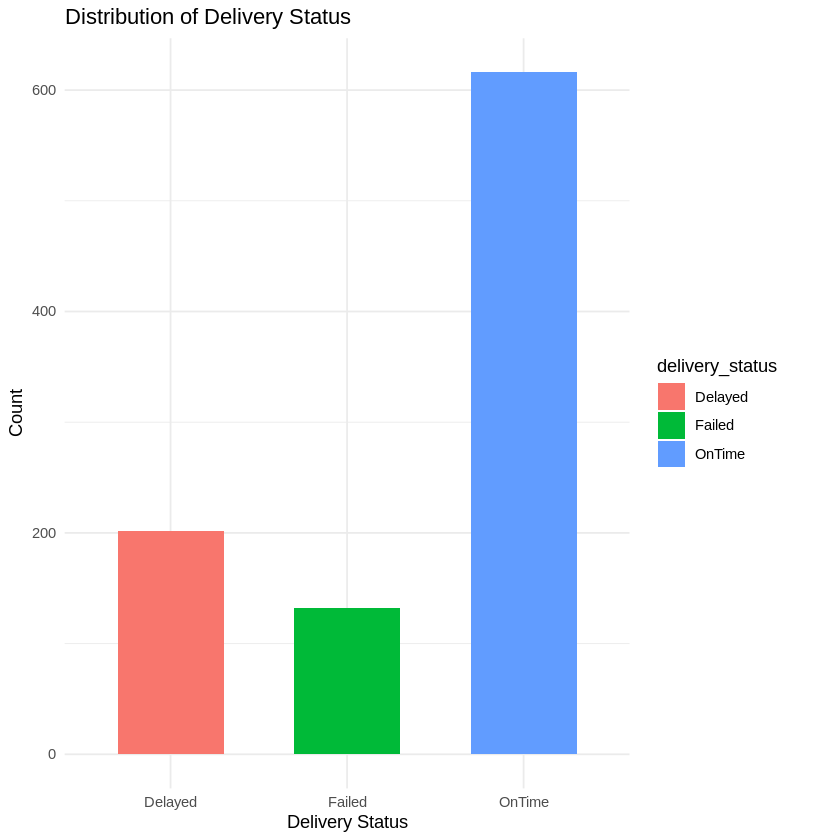

In [ ]:
library(ggplot2)
library(dplyr)

delivery_status_plot <- deliveries %>%
  count(delivery_status) %>%
  ggplot(aes(x = delivery_status, y = n, fill = delivery_status)) +
  geom_col(width = 0.6) +
  labs(
    title = "Distribution of Delivery Status",
    x = "Delivery Status",
    y = "Count"
  ) +
  theme_minimal()

delivery_status_plot

This chart is included to show how many deliveries were completed on time, delayed, or failed. It is a simple but important visual because delivery reliability is one of the main problems in the case study, so this gives a clear first view of service performance.

## Complaint type distribution
Objective:

To identify the most common customer complaint categories through visual analysis.

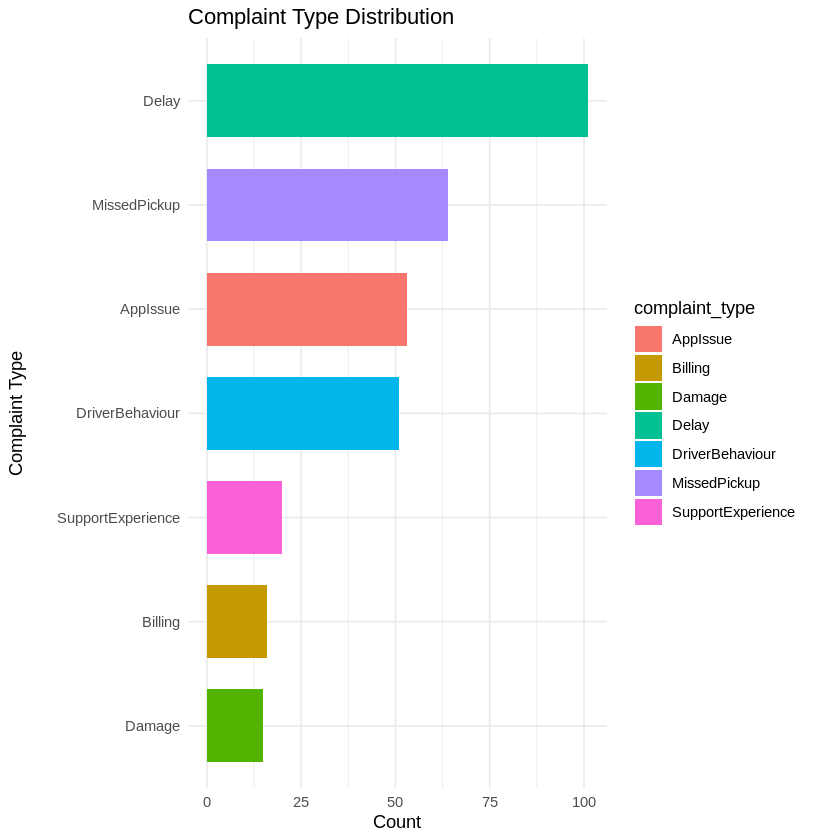

In [ ]:
complaint_type_plot <- complaints %>%
  count(complaint_type) %>%
  ggplot(aes(x = reorder(complaint_type, n), y = n, fill = complaint_type)) +
  geom_col(width = 0.7) +
  coord_flip() +
  labs(
    title = "Complaint Type Distribution",
    x = "Complaint Type",
    y = "Count"
  ) +
  theme_minimal()

complaint_type_plot

We use this chart to see which complaint types happen most often, such as delays, missed pickups, or app issues. This helps us connect customer dissatisfaction to the underlying operational problems instead of just reporting complaint numbers.



## Complaint severity distribution
Objective:

To examine how serious the complaints are and determine whether service issues are mostly minor or significant.



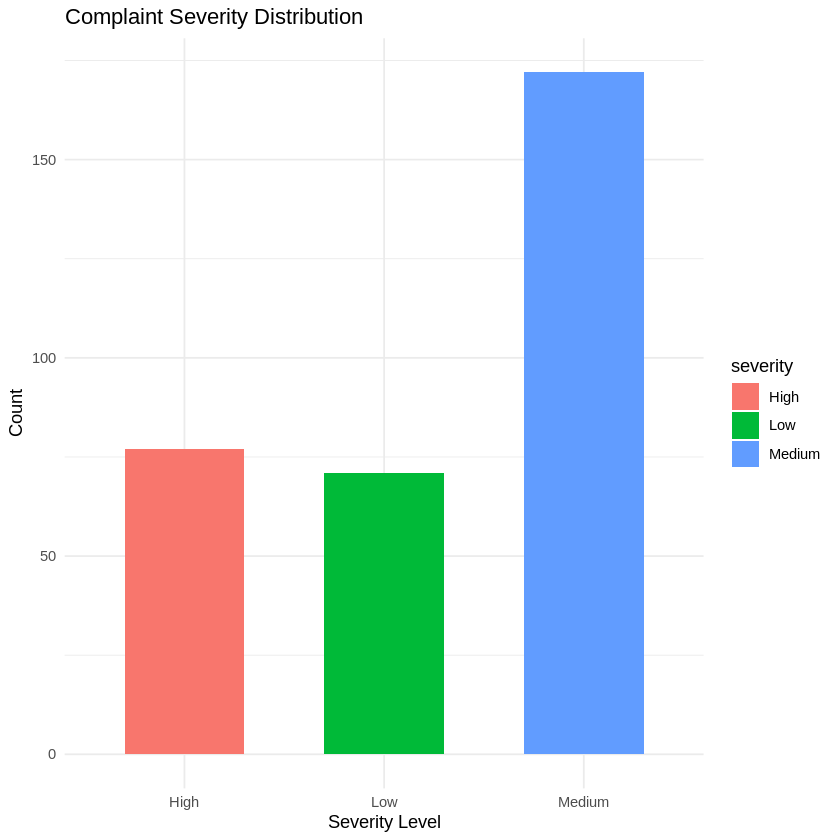

In [ ]:
complaint_severity_plot <- complaints %>%
  count(severity) %>%
  ggplot(aes(x = severity, y = n, fill = severity)) +
  geom_col(width = 0.6) +
  labs(
    title = "Complaint Severity Distribution",
    x = "Severity Level",
    y = "Count"
  ) +
  theme_minimal()

complaint_severity_plot

This step helps us understand whether the complaint volume is made up mostly of low-level issues or whether medium and high severity cases are common. If serious complaints are frequent, it means the service failures are more damaging and require stronger operational action.



## Incident type distribution
Objective:

To visualise the most frequent operational incident types affecting service performance.

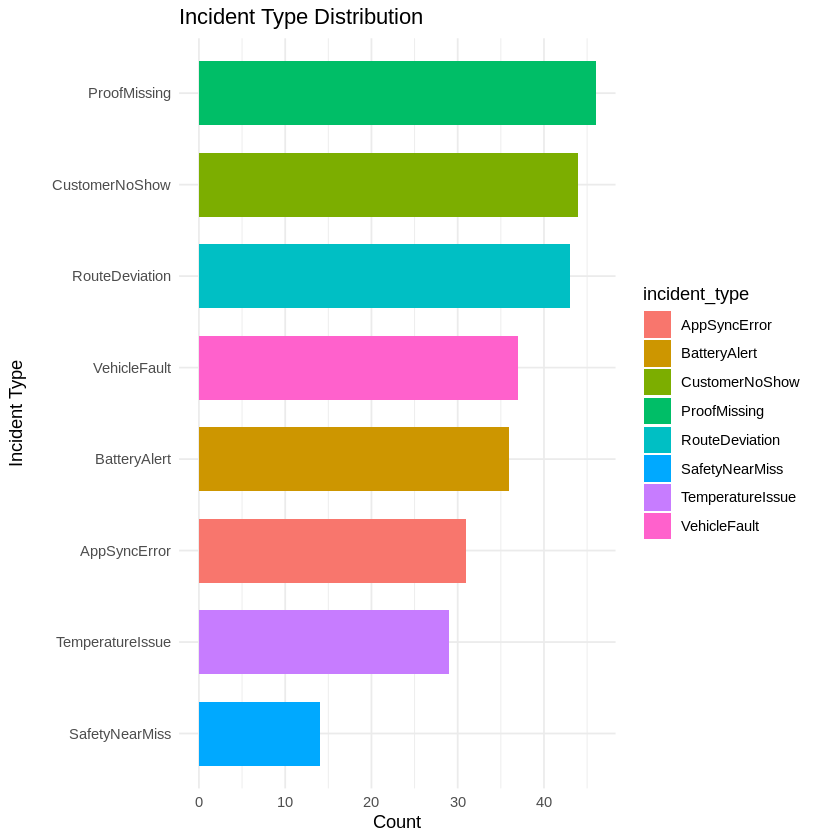

In [ ]:
incident_type_plot <- incidents %>%
  count(incident_type) %>%
  ggplot(aes(x = reorder(incident_type, n), y = n, fill = incident_type)) +
  geom_col(width = 0.7) +
  coord_flip() +
  labs(
    title = "Incident Type Distribution",
    x = "Incident Type",
    y = "Count"
  ) +
  theme_minimal()

incident_type_plot

This chart shows which operational exceptions appear most frequently, such as route deviation, proof missing, or customer no-show. We use it because incident data helps explain why deliveries may fail or why customers may raise complaints.

## Customer rating distribution
Objective:

To analyse post-delivery customer ratings and assess overall customer satisfaction levels.

Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_bin()`).”


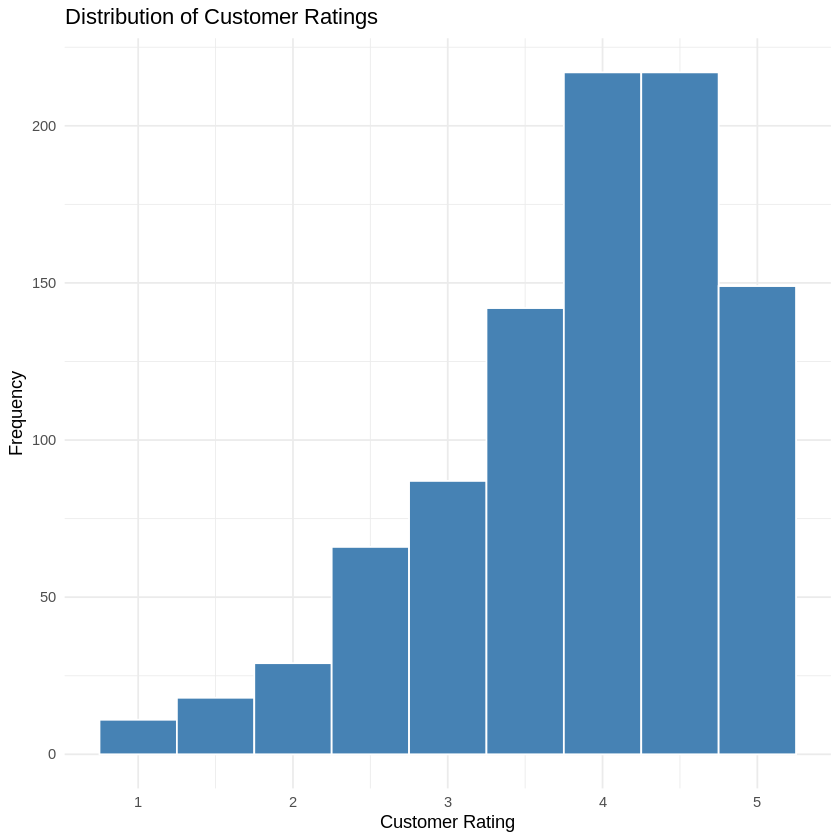

In [ ]:
rating_plot <- deliveries %>%
  ggplot(aes(x = customer_rating_post_delivery)) +
  geom_histogram(binwidth = 0.5, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Customer Ratings",
    x = "Customer Rating",
    y = "Frequency"
  ) +
  theme_minimal()

rating_plot

This step helps us understand how customers rated the service after delivery. We include it because customer satisfaction is one of the key outcomes affected by delay, failed service, and poor operational execution.



## Manual route overrides analysis
Objective:

To examine how often drivers manually override planned routes and assess whether route planning may be a source of inefficiency.



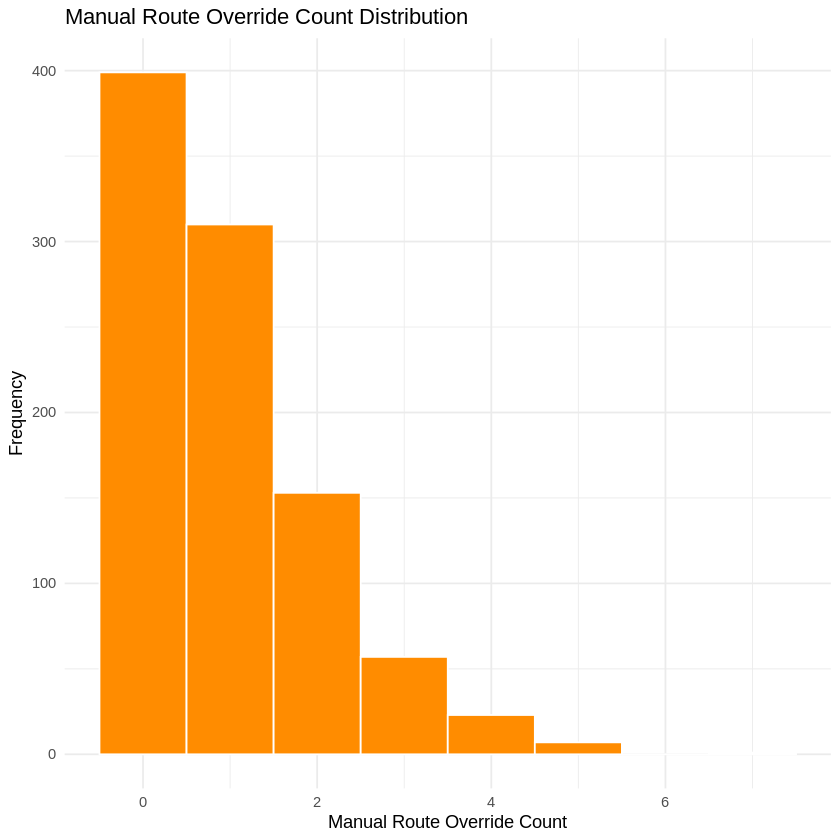

In [ ]:
override_plot <- deliveries %>%
  ggplot(aes(x = manual_route_override_count)) +
  geom_histogram(binwidth = 1, fill = "darkorange", color = "white") +
  labs(
    title = "Manual Route Override Count Distribution",
    x = "Manual Route Override Count",
    y = "Frequency"
  ) +
  theme_minimal()

override_plot

This chart is useful because manual route overrides can indicate poor route planning, road issues, or operational exceptions. We analyse it to see whether route intervention is a normal pattern or a sign of deeper inefficiency.



## Delivery cost analysis
Objective:

To summarise fuel or charging costs and understand the distribution of delivery operating cost.

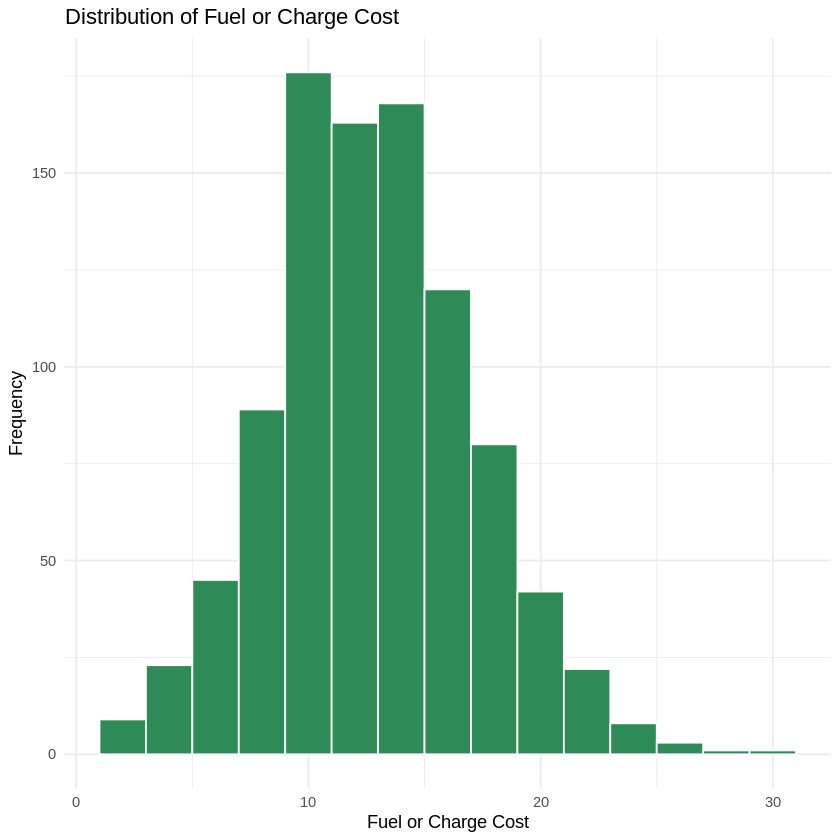

In [ ]:
cost_plot <- deliveries %>%
  ggplot(aes(x = fuel_or_charge_cost)) +
  geom_histogram(binwidth = 2, fill = "seagreen", color = "white") +
  labs(
    title = "Distribution of Fuel or Charge Cost",
    x = "Fuel or Charge Cost",
    y = "Frequency"
  ) +
  theme_minimal()

cost_plot

This analysis is included to understand whether delivery cost is concentrated in a few expensive jobs or spread more evenly across the system. It supports the finance-related part of the case study by showing whether cost escalation might be linked to route complexity or delivery inefficiency.



## Zone-level order volume
Objective:

To compare order volumes across pickup zones and identify whether some zones experience heavier service demand than others.

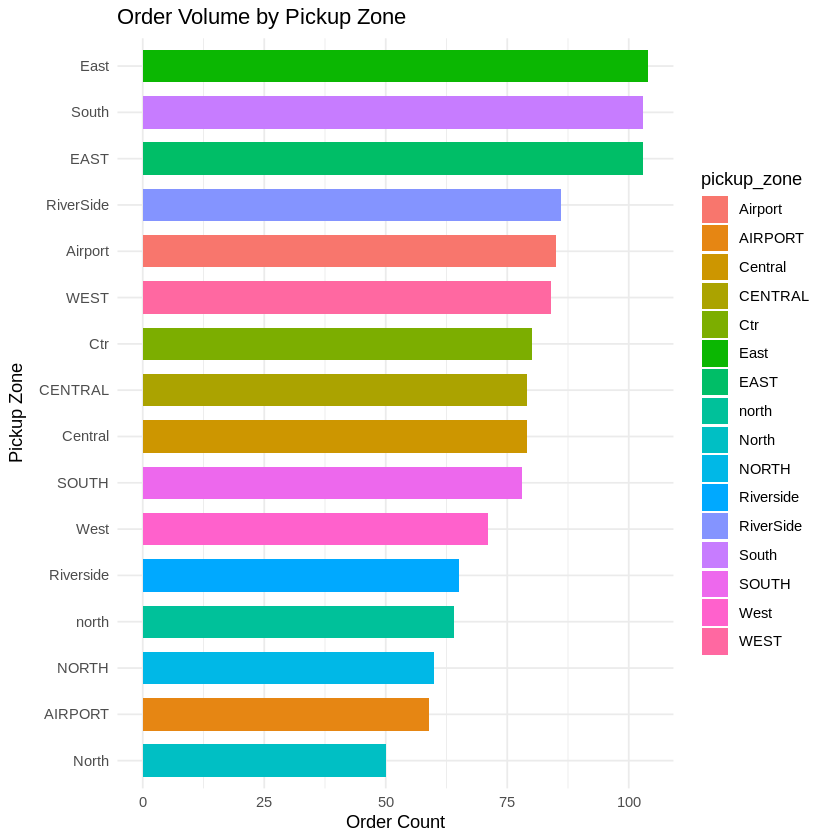

In [ ]:
zone_volume_plot <- orders %>%
  count(pickup_zone) %>%
  ggplot(aes(x = reorder(pickup_zone, n), y = n, fill = pickup_zone)) +
  geom_col(width = 0.7) +
  coord_flip() +
  labs(
    title = "Order Volume by Pickup Zone",
    x = "Pickup Zone",
    y = "Order Count"
  ) +
  theme_minimal()

zone_volume_plot


This chart helps us identify which zones handle the largest amount of demand. We include it because the case study says some city zones perform worse than others, so order volume can help us judge whether poor performance is linked to heavier workload or operational imbalance.



## Boxplot: rating by delivery status
Objective:

To compare customer ratings across OnTime, Delayed, and Failed deliveries.



Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


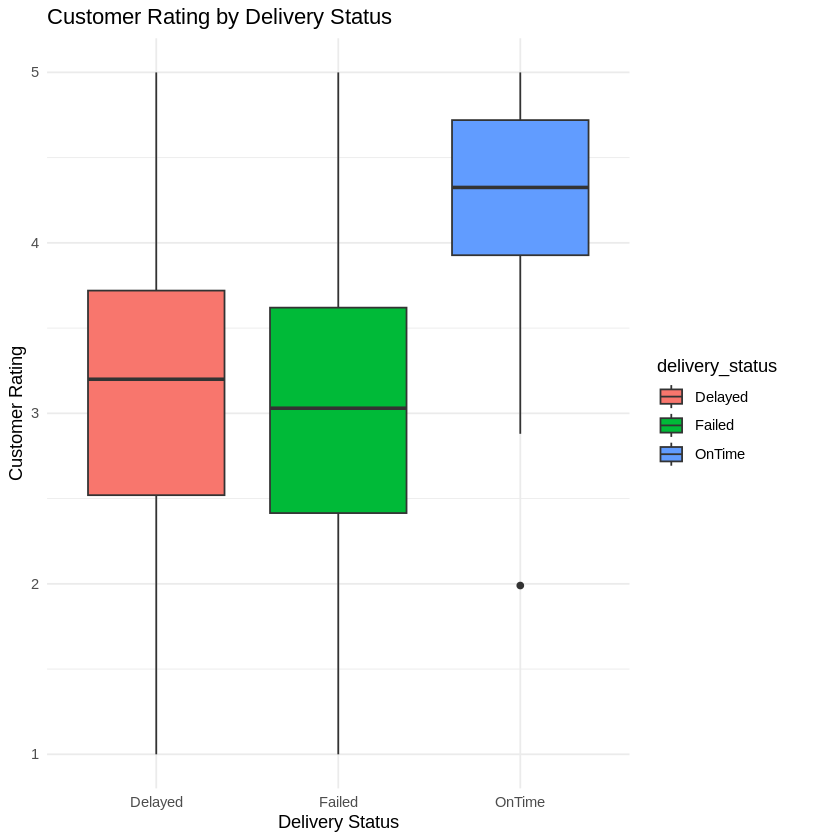

In [ ]:
rating_status_plot <- deliveries %>%
  ggplot(aes(x = delivery_status, y = customer_rating_post_delivery, fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Customer Rating"
  ) +
  theme_minimal()

rating_status_plot

This boxplot helps us compare customer satisfaction across different service outcomes. We include it because if delayed or failed deliveries have lower ratings, it clearly shows that operational failure is affecting the customer experience.

